<a href="https://colab.research.google.com/github/r-salimi/BigMarket-Sales/blob/main/BigMart_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BigMart Sales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
df = pd.read_csv('BigMart Sales.csv')

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
# Check the proportion of missing values in each column
missing_values = (df.isnull().mean()* 100).sort_values(ascending=False)
missing_values

,0
Outlet_Size,28.276428
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Identifier,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Outlet_Identifier,0.000000
Item_MRP,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Location_Type,0.000000


In [4]:
# Check the number of unique values in each column
df.nunique().sort_values()

,0
Outlet_Location_Type,3
Outlet_Size,3
Outlet_Type,4
Item_Fat_Content,5
Outlet_Establishment_Year,9
Outlet_Identifier,10
Item_Type,16
Item_Weight,415
Item_Identifier,1559
Item_Outlet_Sales,3493


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
# Calculate the percentage distribution of outlet types
df['Outlet_Type'].value_counts(normalize=True) * 100

,proportion
Outlet_Type,
Supermarket Type1,65.434706
Grocery Store,12.706793
Supermarket Type3,10.970316
Supermarket Type2,10.888185


In [7]:
values, counts = np.unique(df['Item_Fat_Content'], return_counts=True)
print('unique values:', values, '=>', counts)

unique values: ['LF' 'Low Fat' 'Regular' 'low fat' 'reg'] => [ 316 5089 2889  112  117]


###### Categorical column contain multiple representations of the same value. For example, "Low Fat" and "LF" refer to the same category, while "Regular" and "reg" are also equivalent. So to ensure consistency across the dataset, we map alternative representations to a single standardized value:

In [8]:
# Normalize inconsistent category labels to ensure consistent representation
mapping = {
    "low fat": "Low Fat",
    "lf": "Low Fat",
    "regular": "Regular",
    "reg": "Regular"
}

df["Item_Fat_Content"] = (
    df["Item_Fat_Content"]
    .str.strip()
    .str.lower()
    .replace(mapping)
)

df['Item_Fat_Content'].value_counts(normalize=True).mul(100).round(2)

,proportion
Item_Fat_Content,
Low Fat,64.73
Regular,35.27


In [9]:
# Check for repeated item identifiers
sum(df['Item_Identifier'].duplicated())
# df[df['Item_Identifier'].duplicated(keep=first)]
# df2 = df[~df.Item_Identifier.duplicated(keep='first')]

6964

In [10]:
# Check the number of unique values across all features
df.nunique().sort_values()

,0
Item_Fat_Content,2
Outlet_Size,3
Outlet_Location_Type,3
Outlet_Type,4
Outlet_Establishment_Year,9
Outlet_Identifier,10
Item_Type,16
Item_Weight,415
Item_Identifier,1559
Item_Outlet_Sales,3493


In [11]:
# Calculate outlet age using a fixed reference year
reference_year = 2026
df["OutletAge"] = reference_year - df["Outlet_Establishment_Year"]
df.drop(columns=["Outlet_Establishment_Year"], inplace=True)

In [12]:
# Extract the item category from the item identifier prefix
df["Item_Category"] = df["Item_Identifier"].str[:2]
print(df["Item_Category"].value_counts())

# Drop the high-cardinality item identifier after extracting useful information
df.drop(columns=["Item_Identifier"], inplace=True)

Item_Category
FD    6125
NC    1599
DR     799
Name: count, dtype: int64


In [13]:
# Separate features from the target variable
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [14]:
# Identify numerical features for exploratory analysis
numeric_columns = X.select_dtypes(include="number").columns.tolist()
numeric_columns

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'OutletAge']

In [15]:
# Identify categorical features for exploratory analysis
categorical_columns = X.select_dtypes(include="object").columns.tolist()
for categorical_column in categorical_columns:
    print('________________')
    print(categorical_column)
    print('----------------')
    print(X[categorical_column].value_counts(dropna=False))

________________
Item_Fat_Content
----------------
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64
________________
Item_Type
----------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
________________
Outlet_Identifier
----------------
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64
________________
Outlet_Size
----------------
Outlet_Size
Medium    2793
NaN  

array([[<Axes: title={'center': 'Item_Weight'}>,
        <Axes: title={'center': 'Item_Visibility'}>],
       [<Axes: title={'center': 'Item_MRP'}>,
        <Axes: title={'center': 'OutletAge'}>]], dtype=object)

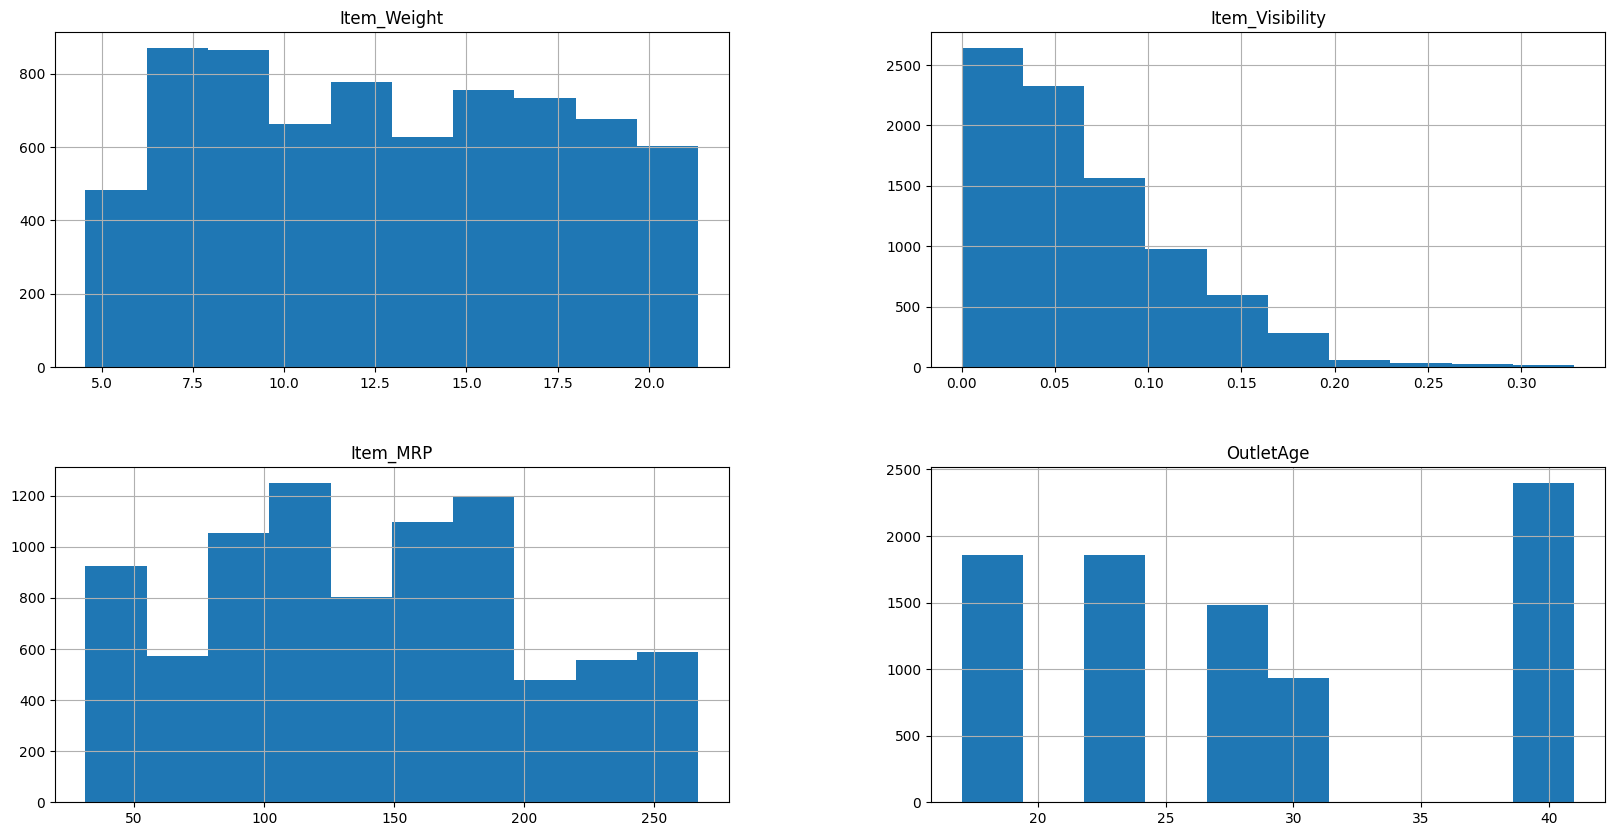

In [16]:
# Visualize the distributions of numerical features
X[numeric_columns].hist(figsize=(20, 10))

In [17]:
# Generate descriptive statistics for numerical features
X[numeric_columns].describe()

,Item_Weight,Item_Visibility,Item_MRP,OutletAge
count,7060.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,28.168133
std,4.643456,0.051598,62.275067,8.371760
min,4.555000,0.000000,31.290000,17.000000
25%,8.773750,0.026989,93.826500,22.000000
50%,12.600000,0.053931,143.012800,27.000000
75%,16.850000,0.094585,185.643700,39.000000
max,21.350000,0.328391,266.888400,41.000000


In [18]:
# Generate an automated exploratory data analysis report
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_notebook_iframe()


/tmp/ipykernel_28198/644056100.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 12.15it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
average_sales = (
    df.groupby('Item_Type')['Item_Outlet_Sales']
    .mean()
    .sort_values(ascending=False)
)

average_sales

,Item_Outlet_Sales
Item_Type,
Starchy Foods,2374.332773
Seafood,2326.065928
Fruits and Vegetables,2289.009592
Snack Foods,2277.321739
Household,2258.784300
Dairy,2232.542597
Canned,2225.194904
Breads,2204.132226
Meat,2158.977911


In [20]:
%matplotlib inline

# Compare average outlet sales across different categories of a selected column.
def plot_average_sales(column):
    average_sales = (
        df.groupby(column)['Item_Outlet_Sales']
        .mean()
        .sort_values(ascending=False)
    )

    average_sales.plot(
        kind='bar',
        figsize=(6, 4)
    )

    plt.title(f'Average Sales by {column}')
    plt.xlabel(column)
    plt.ylabel('Average Sales')
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

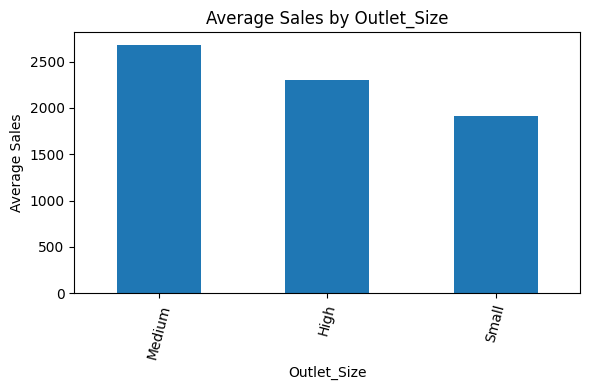

In [21]:
plot_average_sales('Outlet_Size')

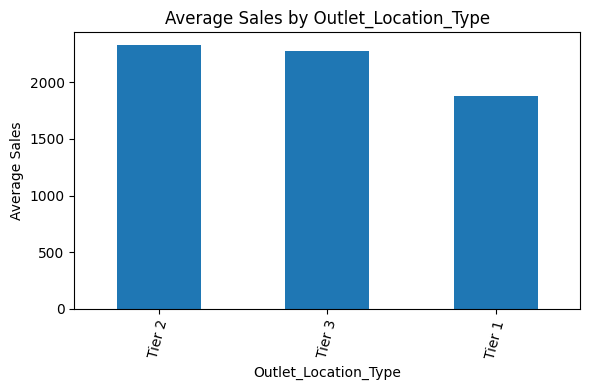

In [22]:
plot_average_sales('Outlet_Location_Type')

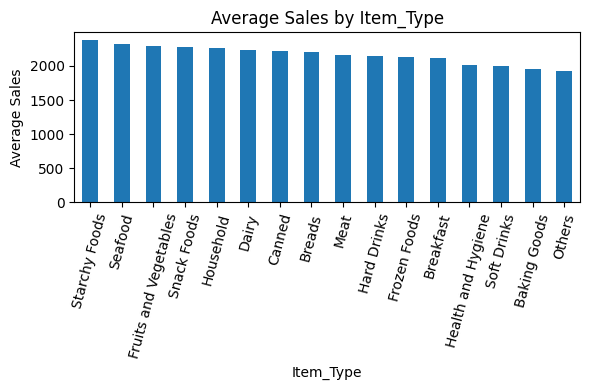

In [23]:
plot_average_sales('Item_Type')

#### Average Sales by Item Type

Calculate the average outlet sales for each item type and sort the results from the lowest to the highest average sales.


In [24]:
df.groupby("Item_Type")["Item_Outlet_Sales"].mean().sort_values()

,Item_Outlet_Sales
Item_Type,
Others,1926.139702
Baking Goods,1952.971207
Soft Drinks,2006.511735
Health and Hygiene,2010.000265
Breakfast,2111.808651
Frozen Foods,2132.867744
Hard Drinks,2139.221622
Meat,2158.977911
Breads,2204.132226


In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
categorical_cols = ['Item_Fat_Content',
                    'Item_Type',
                    'Outlet_Location_Type',
                    'Outlet_Type']

ordinal_cols = ['Outlet_Size']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]


df_ordinal = df[ordinal_cols]
df_nominal = df[nominal_cols]

#### Numerical Feature Preprocessing

Create a preprocessing pipeline for numerical features by imputing missing values using KNN and then standardizing the features using `StandardScaler`.


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)),
    ('scaler', StandardScaler())
])

In [28]:
KNNImputer(n_neighbors=3)

KNNImputer(n_neighbors=3)

#### Categorical Feature Preprocessing

Missing values in categorical features are replaced with the most frequent category. The categorical variables are then transformed using one-hot encoding. The `handle_unknown='ignore'` option ensures that unseen categories in the test data do not cause errors during prediction.


In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [30]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['Small', 'Medium', 'High']]
    ))
])


#### Combining Preprocessing Pipelines

Combine the numerical and categorical preprocessing pipelines using `ColumnTransformer`. Each pipeline is applied only to its corresponding set of features.


In [31]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_columns),
    ('cat', categorical_pipeline, categorical_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
])

#### K-Nearest Neighbors Regression

Build a complete machine learning pipeline that preprocesses the input features and uses K-Nearest Neighbors Regression with five neighbors to predict outlet sales.


In [32]:
from sklearn.neighbors import KNeighborsRegressor

pipe_3 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

In [33]:
pipe_3.fit(X_train, y_train)
y_pred = pipe_3.predict(X_test)

#### Model Evaluation

Evaluate the model's predictive performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R². Lower MAE, MSE, and RMSE indicate better performance, while a higher R² indicates a better fit.


In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R²:', r2)

MAE: 811.1309020997068
MSE: 1337214.4749562596
RMSE: 1156.379900792235
R²: 0.5080098594975334


In [35]:
from sklearn.dummy import DummyRegressor

baseline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R²:", r2_score(y_test, baseline_pred))

Baseline MAE: 1321.738728500184
Baseline RMSE: 1651.989750472933
Baseline R²: -0.004083955591431154


In [37]:
from sklearn.linear_model import LinearRegression

linear_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

linear_pipe.fit(X_train, y_train)

linear_pred = linear_pipe.predict(X_test)

In [38]:
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R²:", r2_score(y_test, linear_pred))

MAE: 792.6846341877616
RMSE: 1070.738303022063
R²: 0.5781850110712643


In [39]:
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=0.1))
])

ridge_pipe.fit(X_train, y_train)

ridge_pred = ridge_pipe.predict(X_test)

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

rf_pred = rf_pipe.predict(X_test)

In [41]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }

results = {}
results['KNN'] = evaluate_model(
    pipe_3,
    X_test,
    y_test
)

results['Linear Regression'] = evaluate_model(
    linear_pipe,
    X_test,
    y_test
)
results['Ridge'] = evaluate_model(
    ridge_pipe,
    X_test,
    y_test
)

results['Random Forest'] = evaluate_model(
    rf_pipe,
    X_test,
    y_test
)



In [42]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(by='RMSE')
results_df

,MAE,MSE,RMSE,R²
Linear Regression,792.684634,1.146481e+06,1070.738303,0.578185
Ridge,792.685229,1.146484e+06,1070.740119,0.578184
Random Forest,761.724090,1.193703e+06,1092.567015,0.560811
KNN,811.130902,1.337214e+06,1156.379901,0.508010


<Axes: >

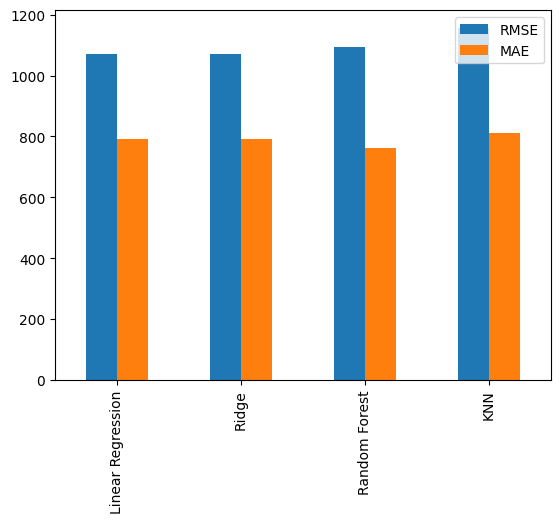

In [43]:
results_df[['RMSE', 'MAE']].plot(kind='bar')

#### Cross-Validation

Use 5-fold cross-validation on the training set to obtain a more robust estimate of the Ridge Regression model's performance. The data is shuffled before splitting, with a fixed random state to ensure reproducibility.


In [44]:
from sklearn.model_selection import cross_validate, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = cross_validate(
    ridge_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }
)

# Ridge Hyperparameter Tuning
results = []

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:

    ridge_pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])

    cv_results = cross_validate(
        ridge_pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        }
    )

    results.append({
        'alpha': alpha,
        'MAE_mean': -cv_results['test_MAE'].mean(),
        'MAE_std': cv_results['test_MAE'].std(),
        'RMSE_mean': -cv_results['test_RMSE'].mean(),
        'RMSE_std': cv_results['test_RMSE'].std(),
        'R2_mean': cv_results['test_R2'].mean(),
        'R2_std': cv_results['test_R2'].std()
    })

### Cross-Validation Results
ridge_results = pd.DataFrame(results)
ridge_results

,alpha,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,0.001,853.152106,16.303437,1149.210811,28.780469,0.552207,0.012441
1,0.010,853.151380,16.303503,1149.210528,28.780899,0.552207,0.012441
2,0.100,853.144123,16.304156,1149.207720,28.785196,0.552209,0.012437
3,1.000,853.073200,16.310695,1149.180931,28.827713,0.552232,0.012404
4,10.000,852.467496,16.402675,1149.028726,29.216800,0.552367,0.012090
5,100.000,852.387134,16.783364,1153.826575,31.879611,0.548722,0.010181
6,1000.000,924.400372,19.573552,1251.249834,40.432347,0.469527,0.007311


In [45]:
# Find the best alpha based on cross-validation RMSE
best_alpha = ridge_results.loc[
    ridge_results['RMSE_mean'].idxmin(),
    'alpha'
]

print("Best alpha:", best_alpha)

Best alpha: 10.0


In [46]:
final_ridge = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=best_alpha))
])

final_ridge.fit(X_train, y_train)

final_pred = final_ridge.predict(X_test)

In [47]:
print("Final Ridge MAE:", mean_absolute_error(y_test, final_pred))
print("Final Ridge RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))
print("Final Ridge R²:", r2_score(y_test, final_pred))

Final Ridge MAE: 792.8069666283147
Final Ridge RMSE: 1070.9861330214644
Final Ridge R²: 0.5779897243121417


In [48]:
linear_pipe.fit(X_train, y_train)

linear_pred = linear_pipe.predict(X_test)

print("Linear Regression MAE:",
      mean_absolute_error(y_test, linear_pred))

print("Linear Regression RMSE:",
      np.sqrt(mean_squared_error(y_test, linear_pred)))

print("Linear Regression R²:",
      r2_score(y_test, linear_pred))

Linear Regression MAE: 792.6846341877616
Linear Regression RMSE: 1070.738303022063
Linear Regression R²: 0.5781850110712643


Linear Regression was selected as the final model because it achieved the best overall test-set performance based on RMSE and R².: